# Duolingo Forgetting Prediction

Predicting vocabulary recall probability from historical
learning behavior using Duolingo learning trace data.

In [ ]:
#setup


import os
import gc

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import userdata
import os

os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")



In [ ]:
#download dataset

!mkdir -p data

!kaggle datasets download \
    kylefengkfeng209/how-fast-do-you-forget-13m-duolingo-sessions \
    -p data \
    --unzip

Dataset URL: https://www.kaggle.com/datasets/kylefengkfeng209/how-fast-do-you-forget-13m-duolingo-sessions
License(s): CC-BY-NC-SA-4.0
100% 17.1M/17.1M [00:02<00:00, 8.35MB/s]



### Problem Definition

Predict a learner's probability of recalling a vocabulary item based on previous learning interactions.

### Dataset Understanding

In [ ]:
#dataset

import pandas as pd
dataset = pd.read_csv("data/learning_traces_sample.csv")

dataset

,practice_time,user_id,ui_language,learning_language,surface_form,lemma,pos,grammar_tags,lag_days,history_seen,history_correct,session_seen,session_correct,p_recall,lexeme_id
0,2013-02-28 20:11:37,u:FO,en,de,lernt,lernen,vblex,pri;p3;sg,0.003,14,12,1,0,0.000000,76390c1350a8dac31186187e2fe1e178
1,2013-02-28 20:14:53,u:g3WM,en,pt,leão,leão,n,m;sg,0.017,9,8,1,1,1.000000,4b3613233b3fede2e3e92ac2ef752bf6
2,2013-02-28 20:14:53,u:g3WM,en,pt,roupa,roupa,n,f;*numb,13.791,1,1,1,1,1.000000,3a898602c268f23d8acbeadacc9138be
3,2013-02-28 20:15:21,u:hl1O,en,de,nudeln,nudel,n,f;pl;*case,20.451,2,2,3,2,0.666667,3fb0c6ae83598ec3e6817e2e236e3b9b
4,2013-02-28 20:15:27,u:h5ex,en,de,zucker,zucker,n,m;sg;dat,0.002,2,1,1,1,1.000000,a8f2e402075e0670edf17d20c1329fa9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499431,2013-03-12 16:14:48,u:jdQ2,en,de,esst,essen,vblex,pri;p2;pl,1.166,5,4,3,3,1.000000,2429597b6723a98e21068629ab3f4231
499432,2013-03-12 16:14:51,u:hxsA,es,en,pay,pay,vblex,pres,0.004,19,17,1,0,0.000000,f6046c6b9b9cf8aa728d386c7e6100f5
499433,2013-03-12 16:14:51,u:i2Of,en,es,bebemos,beber,vblex,pri;p1;pl,0.065,6,5,2,2,1.000000,a8a620e1310deb6282fec185918acad1
499434,2013-03-12 16:14:51,u:i2Of,en,es,vino,vino,n,m;sg,0.065,11,10,2,2,1.000000,3c317e367d8d299c237e618dd5dde5da


In [ ]:
dataset.head()

,practice_time,user_id,ui_language,learning_language,surface_form,lemma,pos,grammar_tags,lag_days,history_seen,history_correct,session_seen,session_correct,p_recall,lexeme_id
0,2013-02-28 20:11:37,u:FO,en,de,lernt,lernen,vblex,pri;p3;sg,0.003,14,12,1,0,0.000000,76390c1350a8dac31186187e2fe1e178
1,2013-02-28 20:14:53,u:g3WM,en,pt,leão,leão,n,m;sg,0.017,9,8,1,1,1.000000,4b3613233b3fede2e3e92ac2ef752bf6
2,2013-02-28 20:14:53,u:g3WM,en,pt,roupa,roupa,n,f;*numb,13.791,1,1,1,1,1.000000,3a898602c268f23d8acbeadacc9138be
3,2013-02-28 20:15:21,u:hl1O,en,de,nudeln,nudel,n,f;pl;*case,20.451,2,2,3,2,0.666667,3fb0c6ae83598ec3e6817e2e236e3b9b
4,2013-02-28 20:15:27,u:h5ex,en,de,zucker,zucker,n,m;sg;dat,0.002,2,1,1,1,1.000000,a8f2e402075e0670edf17d20c1329fa9


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499436 entries, 0 to 499435
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   practice_time      499436 non-null  object 
 1   user_id            499436 non-null  object 
 2   ui_language        499436 non-null  object 
 3   learning_language  499436 non-null  object 
 4   surface_form       499436 non-null  object 
 5   lemma              499436 non-null  object 
 6   pos                499436 non-null  object 
 7   grammar_tags       448480 non-null  object 
 8   lag_days           499436 non-null  float64
 9   history_seen       499436 non-null  int64  
 10  history_correct    499436 non-null  int64  
 11  session_seen       499436 non-null  int64  
 12  session_correct    499436 non-null  int64  
 13  p_recall           499436 non-null  float64
 14  lexeme_id          499436 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 57

In [ ]:
dataset.describe()

,lag_days,history_seen,history_correct,session_seen,session_correct,p_recall
count,499436.000000,499436.000000,499436.000000,499436.000000,499436.000000,499436.000000
mean,8.426820,21.795071,19.229473,1.819643,1.645929,0.896076
std,25.921927,132.212007,115.861608,1.362531,1.321230,0.271270
min,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,0.006000,3.000000,3.000000,1.000000,1.000000,1.000000
50%,0.895000,6.000000,6.000000,1.000000,1.000000,1.000000
75%,5.128000,15.000000,13.000000,2.000000,2.000000,1.000000
max,466.389000,13447.000000,12821.000000,20.000000,20.000000,1.000000


In [ ]:
numerical_cols = dataset.select_dtypes(include=['number']).columns
categorical_cols = dataset.select_dtypes(include=['object', 'category']).columns

numerical_data = dataset[numerical_cols]
categorical_data = dataset[categorical_cols]

print("Numerical Data:\n", numerical_data.head())
print("\nCategorical Data:\n", categorical_data.head())

Numerical Data:
    lag_days  history_seen  history_correct  session_seen  session_correct  \
0     0.003            14               12             1                0   
1     0.017             9                8             1                1   
2    13.791             1                1             1                1   
3    20.451             2                2             3                2   
4     0.002             2                1             1                1   

   p_recall  
0  0.000000  
1  1.000000  
2  1.000000  
3  0.666667  
4  1.000000  

Categorical Data:
          practice_time user_id ui_language learning_language surface_form  \
0  2013-02-28 20:11:37    u:FO          en                de        lernt   
1  2013-02-28 20:14:53  u:g3WM          en                pt         leão   
2  2013-02-28 20:14:53  u:g3WM          en                pt        roupa   
3  2013-02-28 20:15:21  u:hl1O          en                de       nudeln   
4  2013-02-28 20:15:27  u:h5ex 

### Data Quality Check

In [ ]:
dataset.isnull().sum().sort_values(ascending=False)

,0
grammar_tags,50956
user_id,0
practice_time,0
learning_language,0
surface_form,0
lemma,0
ui_language,0
pos,0
lag_days,0
history_seen,0


In [ ]:
#checking why grammar_tags has missing values
dataset[dataset["grammar_tags"].isnull()][
    ["surface_form", "lemma", "pos", "grammar_tags"]
].head(20)


,surface_form,lemma,pos,grammar_tags
28,not,not,adv,NaN
30,and,and,cnjcoo,NaN
39,hello,hello,ij,NaN
50,rechts,rechts,adv,NaN
55,in,in,pr,NaN
57,and,and,cnjcoo,NaN
62,plaît,plaire,@adv:s_il_te_plait,NaN
63,ne,ne,adv,NaN
65,que,que,cnjsub,NaN
67,and,and,cnjcoo,NaN


In [ ]:
dataset[dataset["grammar_tags"].isnull()]["pos"].value_counts()

,count
pos,
adv,14674
pr,12858
cnjcoo,6016
ij,5011
adj,4960
...,...
@cnj:apres_que,1
@cnj:bien_que,1
@pr:afin_de,1


In [ ]:
grammar_missing_by_pos = dataset.groupby("pos").agg(
    total_count=("grammar_tags", "size"),
    missing_count=("grammar_tags", lambda x: x.isna().sum())
)

grammar_missing_by_pos["missing_pct"] = (
    grammar_missing_by_pos["missing_count"]
    / grammar_missing_by_pos["total_count"]
    * 100
)

grammar_missing_by_pos.sort_values(
    ["missing_count", "missing_pct"],
    ascending=False
)

,total_count,missing_count,missing_pct
pos,,,
adv,17558,14674,83.574439
pr,15465,12858,83.142580
cnjcoo,6016,6016,100.000000
ij,5011,5011,100.000000
adj,27595,4960,17.974271
...,...,...,...
vaux,319,0,0.000000
vbdo,1336,0,0.000000
vbhaver,1603,0,0.000000


In other words, the absence of grammar_tags certainly does not appear to be random. It is very strongly linked to specific part-of-speech types.

In [ ]:
dataset.duplicated().sum()

np.int64(0)

### EDA

In [ ]:
dataset["p_recall"].describe()

,p_recall
count,499436.000000
mean,0.896076
std,0.271270
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


In [ ]:
dataset["p_recall"].value_counts().head(10)

,count
p_recall,
1.000000,418777
0.000000,35150
0.500000,17554
0.666667,11195
0.750000,6734
0.800000,3697
0.833333,1781
0.333333,1074
0.857143,805


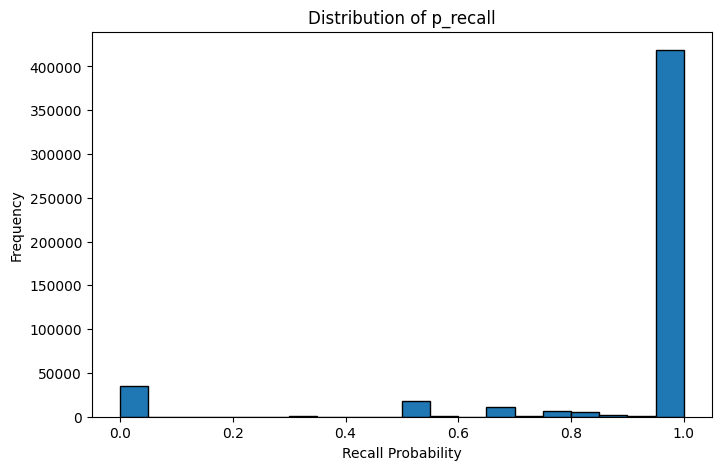

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(dataset["p_recall"], bins=20, edgecolor="black")
plt.xlabel("Recall Probability")
plt.ylabel("Frequency")
plt.title("Distribution of p_recall")
plt.show()

In [ ]:
dataset["session_seen"].value_counts().sort_index()

,count
session_seen,
1,294221
2,102154
3,52963
4,26053
5,12563
6,5646
7,2481
8,1269
9,714


In [ ]:
calculated_recall = dataset["session_correct"] / dataset["session_seen"]

(calculated_recall - dataset["p_recall"]).abs().max()

4.4444444458058285e-08

It was confirmed that p_recall is calculated directly from these two columns, as the difference turned out to be very close to zero. This could lead to data leakage in the future.

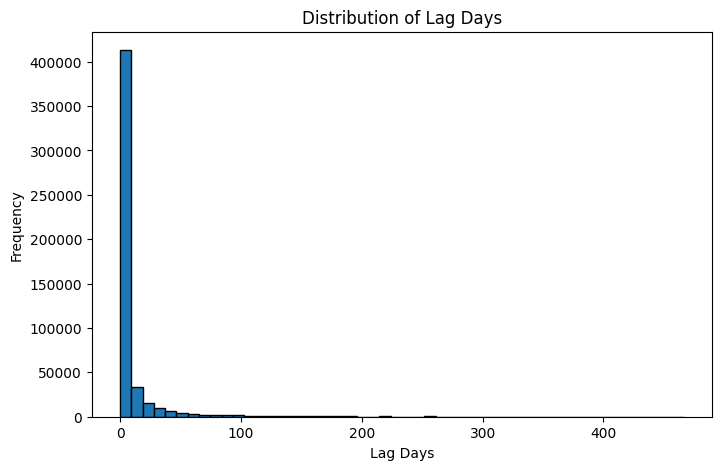

In [ ]:

plt.figure(figsize=(8, 5))
plt.hist(dataset["lag_days"], bins=50, edgecolor="black")
plt.xlabel("Lag Days")
plt.ylabel("Frequency")
plt.title("Distribution of Lag Days")
plt.show()

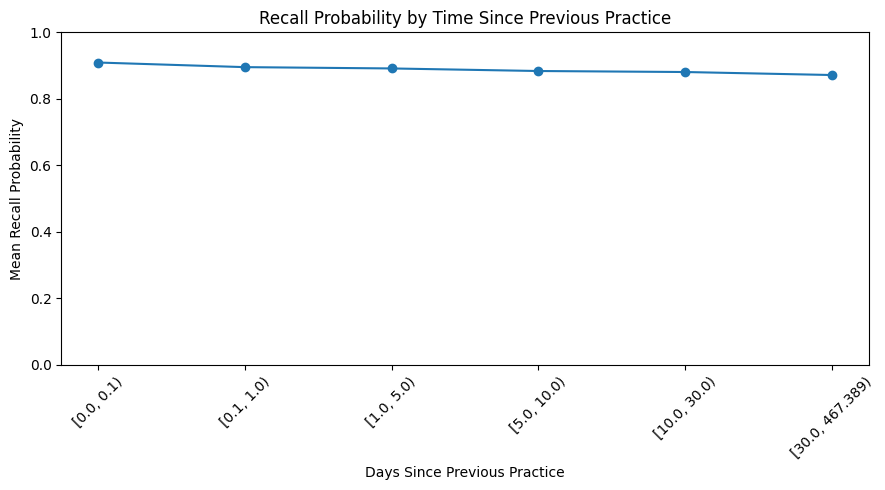

In [ ]:
lag_bins = [0, 0.1, 1, 5, 10, 30, dataset["lag_days"].max() + 1]
dataset["lag_days_group"] = pd.cut(
    dataset["lag_days"],
    bins=lag_bins,
    include_lowest=True,
    right=False
)

lag_recall = dataset.groupby(
    "lag_days_group",
    observed=True
)["p_recall"].agg(["mean", "count"])

plt.figure(figsize=(9, 5))

plt.plot(
    lag_recall.index.astype(str),
    lag_recall["mean"],
    marker="o"
)

plt.xlabel("Days Since Previous Practice")
plt.ylabel("Mean Recall Probability")
plt.title("Recall Probability by Time Since Previous Practice")

plt.xticks(rotation=45)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

right-skewed distribution + weak/moderate negative correlation with recall + a future candidate for log1p.

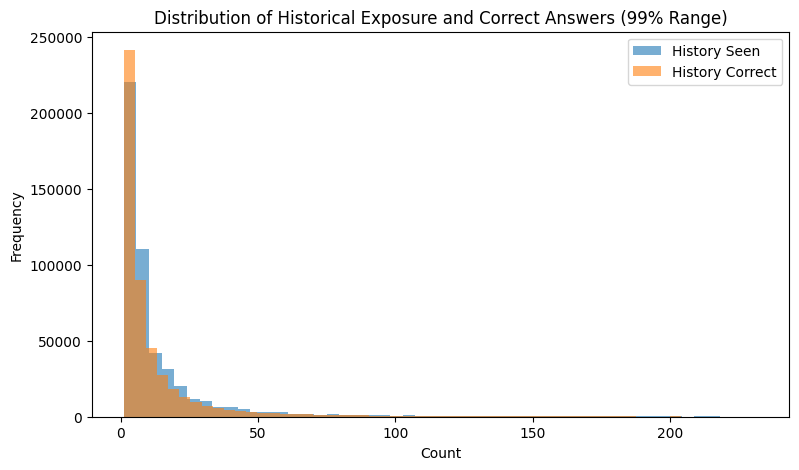

In [ ]:
seen_limit = dataset["history_seen"].quantile(0.99)
correct_limit = dataset["history_correct"].quantile(0.99)

plt.figure(figsize=(9, 5))

plt.hist(
    dataset.loc[dataset["history_seen"] <= seen_limit, "history_seen"],
    bins=50,
    alpha=0.6,
    label="History Seen"
)

plt.hist(
    dataset.loc[dataset["history_correct"] <= correct_limit, "history_correct"],
    bins=50,
    alpha=0.6,
    label="History Correct"
)

plt.xlabel("Count")
plt.ylabel("Frequency")
plt.title("Distribution of Historical Exposure and Correct Answers (99% Range)")
plt.legend()
plt.show()

In [ ]:
dataset["history_accuracy"] = (dataset["history_correct"] / dataset["history_seen"])

dataset['history_accuracy'].describe()

,history_accuracy
count,499436.000000
mean,0.900591
std,0.136263
min,0.090909
25%,0.833333
50%,0.964286
75%,1.000000
max,1.000000


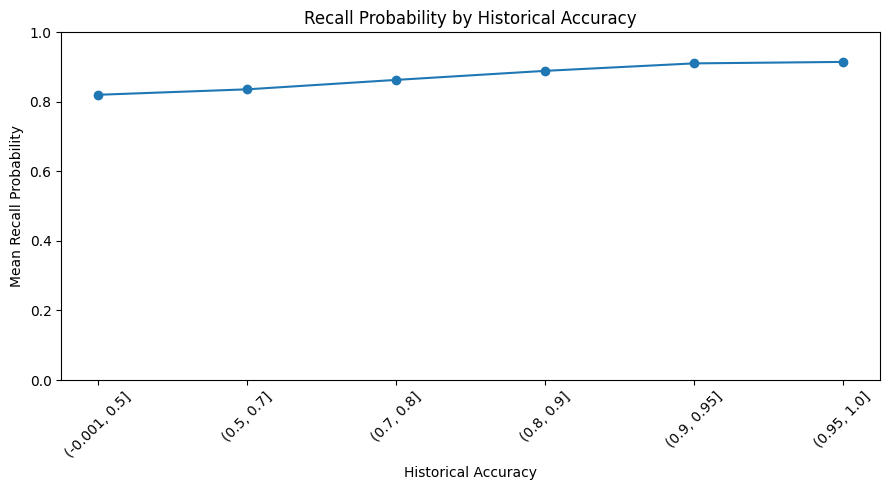

In [ ]:
accuracy_bins = [0, 0.5, 0.7, 0.8, 0.9, 0.95, 1.0]

dataset["history_accuracy_group"] = pd.cut(
    dataset["history_accuracy"],
    bins=accuracy_bins,
    include_lowest=True
)

accuracy_recall = dataset.groupby(
    "history_accuracy_group",
    observed=True
)["p_recall"].agg(["mean", "count"])

plt.figure(figsize=(9, 5))

plt.plot(
    accuracy_recall.index.astype(str),
    accuracy_recall["mean"],
    marker="o"
)

plt.xlabel("Historical Accuracy")
plt.ylabel("Mean Recall Probability")
plt.title("Recall Probability by Historical Accuracy")
plt.ylim(0, 1)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

OHE candidates

In [ ]:
dataset[categorical_cols].nunique().sort_values()


,0
ui_language,4
learning_language,6
pos,73
grammar_tags,585
lemma,6284
surface_form,8367
lexeme_id,11227
user_id,75294
practice_time,286983


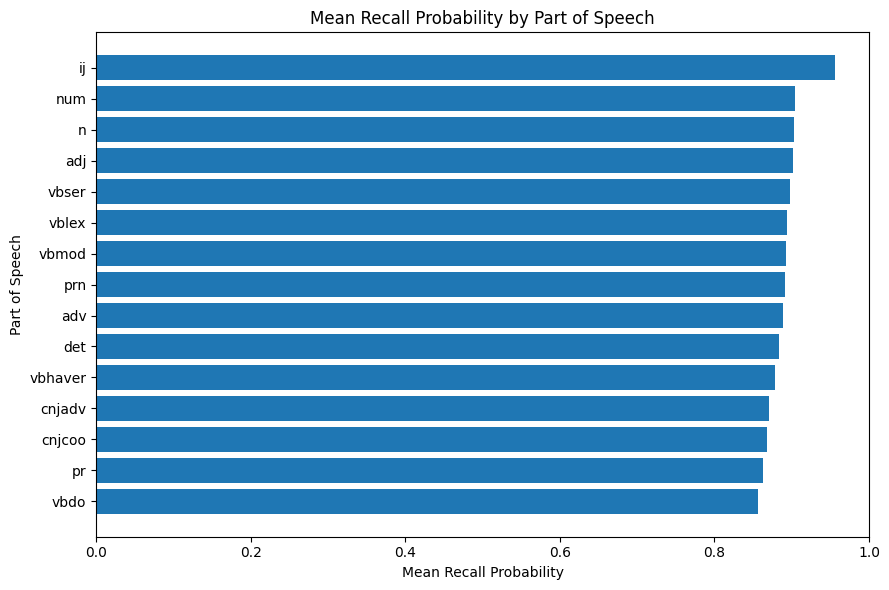

In [ ]:
top_pos = dataset["pos"].value_counts().head(15).index

pos_recall = (
    dataset[dataset["pos"].isin(top_pos)]
    .groupby("pos")["p_recall"]
    .agg(["mean", "count"])
    .sort_values("mean")
)

plt.figure(figsize=(9, 6))

plt.barh(
    pos_recall.index,
    pos_recall["mean"]
)

plt.xlabel("Mean Recall Probability")
plt.ylabel("Part of Speech")
plt.title("Mean Recall Probability by Part of Speech")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

## Other Datasets

In [ ]:
word_difficulty = pd.read_csv("data/word_difficulty.csv")
forgetting_curve = pd.read_csv("data/forgetting_curve.csv")
language_courses = pd.read_csv("data/language_courses.csv")

In [ ]:
#first word_difficulty
print("Shape:", word_difficulty.shape)
print("Columns:", word_difficulty.columns.tolist())

word_difficulty.head()

Shape: (6211, 12)
Columns: ['learning_language', 'language_name', 'surface_form', 'lemma', 'pos', 'grammar_tags', 'n_traces', 'avg_session_recall', 'item_recall_rate', 'avg_prior_exposures', 'difficulty_rank_in_language', 'lexeme_id']


,learning_language,language_name,surface_form,lemma,pos,grammar_tags,n_traces,avg_session_recall,item_recall_rate,avg_prior_exposures,difficulty_rank_in_language,lexeme_id
0,de,German,zweiten,zweit,adj,ord;m;sg;acc,292,0.6050,0.6398,5.04,1,f58ba94f5b6a07312e449a9987637f32
1,de,German,ins,in,pr,NaN,115,0.6116,0.6736,7.37,2,360504826f856ea58070939db6aff198
2,de,German,wegen,wegen,pr,dat,109,0.6656,0.7099,6.06,3,c764a035387dc5bad1c5359f786423e0
3,de,German,größeren,groß,adj,comp;mf;pl;acc;mix,233,0.7103,0.7658,6.84,4,066aadf60b6238605b602ffe0279f993
4,de,German,vieles,viel,det,ind;nt;sg;nom,750,0.7179,0.7704,4.96,5,61ed985e99a3bdc4b497a5e0a46b104d


language_name: redundant column / drop candidate

In [ ]:
word_difficulty.info()



print("Duplicates:", word_difficulty.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6211 entries, 0 to 6210
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   learning_language            6211 non-null   object 
 1   language_name                6211 non-null   object 
 2   surface_form                 6211 non-null   object 
 3   lemma                        6211 non-null   object 
 4   pos                          6211 non-null   object 
 5   grammar_tags                 5457 non-null   object 
 6   n_traces                     6211 non-null   int64  
 7   avg_session_recall           6211 non-null   float64
 8   item_recall_rate             6211 non-null   float64
 9   avg_prior_exposures          6211 non-null   float64
 10  difficulty_rank_in_language  6211 non-null   int64  
 11  lexeme_id                    6211 non-null   object 
dtypes: float64(3), int64(2), object(7)
memory usage: 582.4+ KB
Duplicates: 0


In [ ]:
word_difficulty.isnull().sum()

,0
learning_language,0
language_name,0
surface_form,0
lemma,0
pos,0
grammar_tags,754
n_traces,0
avg_session_recall,0
item_recall_rate,0
avg_prior_exposures,0


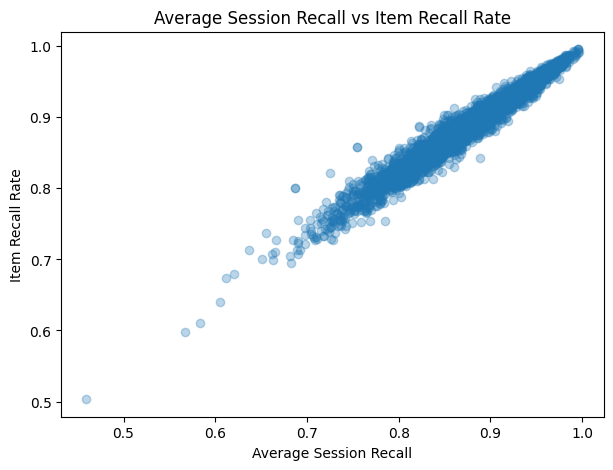

In [ ]:
word_difficulty[
    ["avg_session_recall", "item_recall_rate"]
].corr()
plt.figure(figsize=(7, 5))

plt.scatter(
    word_difficulty["avg_session_recall"],
    word_difficulty["item_recall_rate"],
    alpha=0.3
)

plt.xlabel("Average Session Recall")
plt.ylabel("Item Recall Rate")
plt.title("Average Session Recall vs Item Recall Rate")

plt.show()

There is a very strong, almost linear positive correlation between avg_session_recall and item_recall_rate. In other words, as the average session recall for a word increases, the item recall rate generally increases as well. It would therefore make sense to consider in future whether these two columns need to be included in the model together; they may convey similar information. However, we are not deciding to drop them at this stage.

In [ ]:
language_summary = (
    word_difficulty
    .groupby("language_name")
    .agg(
        word_count=("lexeme_id", "count"),
        mean_session_recall=("avg_session_recall", "mean"),
        mean_item_recall=("item_recall_rate", "mean")
    )
    .sort_values("mean_session_recall")
)

language_summary

,word_count,mean_session_recall,mean_item_recall
language_name,,,
French,869,0.877915,0.886524
German,1026,0.882045,0.893392
Spanish,1366,0.884730,0.896099
English,1782,0.884785,0.894383
Portuguese,382,0.902082,0.907801
Italian,786,0.909167,0.912862


In other words, in this example, the average recall for Italian and Portuguese words is slightly higher, whilst that for French is slightly lower. However, we are talking about a range of approximately 0.878–0.909; therefore, we cannot draw the conclusion that language alone determines recall.

In [ ]:
#second word_difficulty
print("Shape:", forgetting_curve.shape)
print("Columns:", forgetting_curve .columns.tolist())

forgetting_curve.head()

Shape: (310, 10)
Columns: ['learning_language', 'language_name', 'lag_bin', 'lag_bin_order', 'practice_bin', 'practice_bin_order', 'n_traces', 'avg_session_recall', 'item_recall_rate', 'pct_perfect_sessions']


,learning_language,language_name,lag_bin,lag_bin_order,practice_bin,practice_bin_order,n_traces,avg_session_recall,item_recall_rate,pct_perfect_sessions
0,all,All languages,<1 hour,0,1-2 exposures,0,383261,0.9157,0.9191,87.37
1,all,All languages,<1 hour,0,3-4 exposures,1,893452,0.9137,0.9177,86.26
2,all,All languages,<1 hour,0,5-9 exposures,2,1429269,0.9129,0.9186,86.50
3,all,All languages,<1 hour,0,10-19 exposures,3,1023779,0.9129,0.9199,86.00
4,all,All languages,<1 hour,0,20+ exposures,4,1239541,0.8995,0.9097,84.58


In [ ]:
lag_summary = (
    forgetting_curve
    .groupby(["lag_bin_order", "lag_bin"], observed=True)
    .agg(
        avg_recall=("item_recall_rate", "mean"),
        avg_session_recall=("avg_session_recall", "mean"),
        n_traces=("n_traces", "sum")
    )
    .reset_index()
    .sort_values("lag_bin_order")
)

lag_summary

,lag_bin_order,lag_bin,avg_recall,avg_session_recall,n_traces
0,0,<1 hour,0.918697,0.912649,9938604
1,1,1-6 hours,0.904406,0.898123,1235248
2,2,6-24 hours,0.905060,0.898340,2444542
3,3,1-3 days,0.902526,0.894123,3669576
4,4,3-7 days,0.898954,0.889534,3062616
5,5,1-2 weeks,0.896909,0.887037,2026218
6,6,2-4 weeks,0.891229,0.881643,1582588
7,7,1-3 months,0.883291,0.873394,1263538
8,8,3+ months,0.877633,0.860630,485522


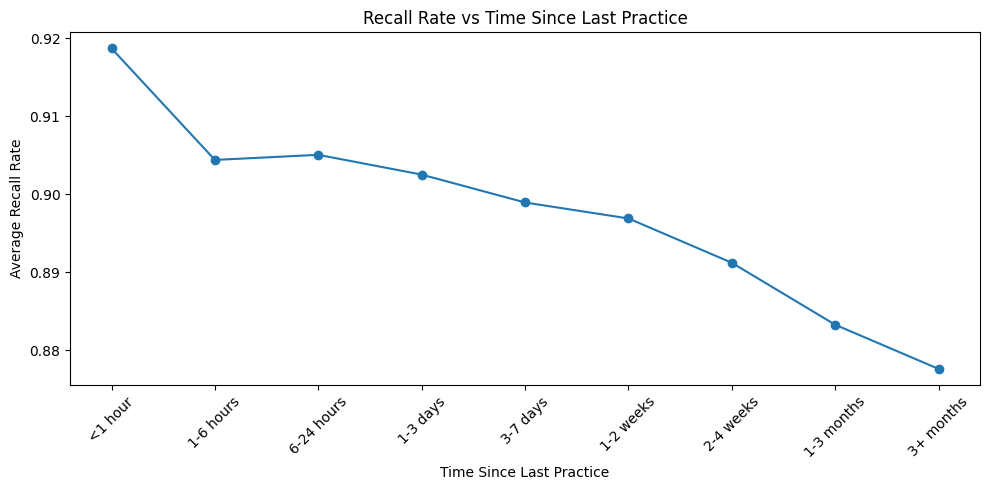

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    lag_summary["lag_bin"],
    lag_summary["avg_recall"],
    marker="o"
)

plt.title("Recall Rate vs Time Since Last Practice")
plt.xlabel("Time Since Last Practice")
plt.ylabel("Average Recall Rate")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#third language_courses
print("Shape:", language_courses.shape)
print("Columns:", language_courses.columns.tolist())
language_courses.head()

Shape: (8, 11)
Columns: ['course', 'ui_language', 'ui_language_name', 'learning_language', 'learning_language_name', 'n_traces', 'n_users', 'avg_session_recall', 'item_recall_rate', 'avg_lag_days', 'avg_prior_exposures']


,course,ui_language,ui_language_name,learning_language,learning_language_name,n_traces,n_users,avg_session_recall,item_recall_rate,avg_lag_days,avg_prior_exposures
0,es -> en,es,Spanish,en,English,3641179,31735,0.8963,0.9039,7.94,39.65
1,en -> es,en,English,es,Spanish,3407689,31155,0.8985,0.9074,10.02,13.07
2,en -> fr,en,English,fr,French,1873734,19947,0.8827,0.8930,8.18,19.46
3,en -> de,en,English,de,German,1452597,14383,0.8928,0.9051,11.08,11.96
4,pt -> en,pt,Portuguese,en,English,949460,8637,0.8987,0.9073,7.14,20.96


In [ ]:
course_summary = language_courses[
    [
        "course",
        "n_users",
        "item_recall_rate",
        "avg_lag_days",
        "avg_prior_exposures"
    ]
].sort_values("item_recall_rate")

course_summary

,course,n_users,item_recall_rate,avg_lag_days,avg_prior_exposures
2,en -> fr,19947,0.8930,8.18,19.46
0,es -> en,31735,0.9039,7.94,39.65
3,en -> de,14383,0.9051,11.08,11.96
4,pt -> en,8637,0.9073,7.14,20.96
1,en -> es,31155,0.9074,10.02,13.07
5,en -> it,6498,0.9117,3.82,10.23
7,en -> pt,2709,0.9121,5.84,12.86
6,it -> en,3436,0.9137,5.76,18.36


Course-level recall rates show moderate variation across language pairs. However, since this dataset contains aggregated statistics rather than individual learning events, it is retained for descriptive analysis and is not directly merged into the prediction dataset to avoid potential information leakage.

### Feature Engineering

In [ ]:
model_data = dataset.copy()

print("Shape:", model_data.shape)
print(model_data.columns.tolist())

Shape: (499436, 18)
['practice_time', 'user_id', 'ui_language', 'learning_language', 'surface_form', 'lemma', 'pos', 'grammar_tags', 'lag_days', 'history_seen', 'history_correct', 'session_seen', 'session_correct', 'p_recall', 'lexeme_id', 'lag_days_group', 'history_accuracy', 'history_accuracy_group']


In [ ]:

model_data["history_incorrect"] = (
    model_data["history_seen"] - model_data["history_correct"]
)

model_data["session_accuracy"] = (
    model_data["session_correct"] /
    model_data["session_seen"].clip(lower=1)
)

model_data["log_lag_days"] = np.log1p(model_data["lag_days"])

model_data["log_history_seen"] = np.log1p(
    model_data["history_seen"]
)

In [ ]:
drop_columns = [
    "practice_time",
    "user_id",
    "surface_form",
    "lemma",
    "grammar_tags",
    "lexeme_id",
    "lag_days_group",
    "history_accuracy_group"
]

model_data = model_data.drop(columns=drop_columns)
#user_id and lexeme_id are cardinalty identifier

In [ ]:
print("Shape:", model_data.shape)
print(model_data.columns.tolist())

Shape: (499436, 14)
['ui_language', 'learning_language', 'pos', 'lag_days', 'history_seen', 'history_correct', 'session_seen', 'session_correct', 'p_recall', 'history_accuracy', 'history_incorrect', 'session_accuracy', 'log_lag_days', 'log_history_seen']


In [ ]:
model_data[
    [
        "session_seen",
        "session_correct",
        "session_accuracy",
        "p_recall"
    ]
].corr()

,session_seen,session_correct,session_accuracy,p_recall
session_seen,1.000000,0.953109,0.041638,0.041638
session_correct,0.953109,1.000000,0.301337,0.301337
session_accuracy,0.041638,0.301337,1.000000,1.000000
p_recall,0.041638,0.301337,1.000000,1.000000


In [ ]:
model_data = model_data.drop(
    columns=[
        "session_seen",
        "session_correct",
        "session_accuracy"
    ]
)

print("Shape:", model_data.shape)
print(model_data.columns.tolist())

Shape: (499436, 11)
['ui_language', 'learning_language', 'pos', 'lag_days', 'history_seen', 'history_correct', 'p_recall', 'history_accuracy', 'history_incorrect', 'log_lag_days', 'log_history_seen']


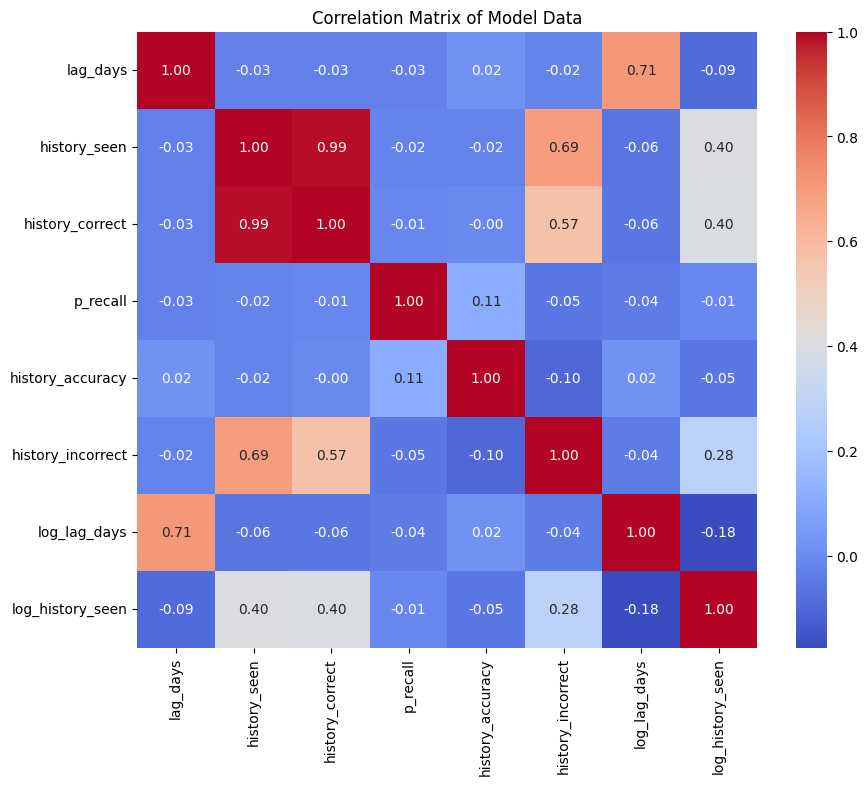

In [ ]:
import seaborn as sns

# Select only numerical columns for correlation matrix
model_data_numeric = model_data.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 8))
sns.heatmap(model_data_numeric.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Model Data')
plt.show()

In [ ]:
model_data = model_data.drop(
    columns=[
        "history_seen",
        "history_correct",
        "history_incorrect"
    ]
)

print(model_data.columns.tolist())

['ui_language', 'learning_language', 'pos', 'lag_days', 'p_recall', 'history_accuracy', 'log_lag_days', 'log_history_seen']


In [ ]:
model_data = dataset.copy()

word_features = word_difficulty[
    [
        "lexeme_id",
        "difficulty_rank_in_language",
        "avg_prior_exposures",
        "n_traces"
    ]
].copy()

model_data = model_data.merge(
    word_features,
    on="lexeme_id",
    how="left"
)
print("Shape:", model_data.shape)
print(model_data.columns.tolist())

Shape: (499436, 21)
['practice_time', 'user_id', 'ui_language', 'learning_language', 'surface_form', 'lemma', 'pos', 'grammar_tags', 'lag_days', 'history_seen', 'history_correct', 'session_seen', 'session_correct', 'p_recall', 'lexeme_id', 'lag_days_group', 'history_accuracy', 'history_accuracy_group', 'difficulty_rank_in_language', 'avg_prior_exposures', 'n_traces']


In [ ]:
new_features = [
    "difficulty_rank_in_language",
    "avg_prior_exposures",
    "n_traces"
]

model_data[new_features].isna().agg(["sum", "mean"])

,difficulty_rank_in_language,avg_prior_exposures,n_traces
sum,9863.000000,9863.000000,9863.000000
mean,0.019748,0.019748,0.019748


In [ ]:
model_data[new_features].describe()

,difficulty_rank_in_language,avg_prior_exposures,n_traces
count,489573.000000,489573.000000,489573.000000
mean,749.215122,22.308148,18005.471078
std,383.506276,30.760006,22168.567523
min,1.000000,1.000000,100.000000
25%,442.000000,6.950000,2744.000000
50%,736.000000,11.590000,10142.000000
75%,1004.000000,25.480000,23156.000000
max,1782.000000,395.540000,123099.000000


In [ ]:
# Missing indicator
model_data["word_features_missing"] = (
    model_data["difficulty_rank_in_language"].isna()
).astype(int)

# Median imputation
fill_cols = [
    "difficulty_rank_in_language",
    "avg_prior_exposures",
    "n_traces"
]

for col in fill_cols:
    model_data[col] = model_data[col].fillna(
        model_data[col].median()
    )

# Log transformations
model_data["log_avg_prior_exposures"] = np.log1p(
    model_data["avg_prior_exposures"]
)

model_data["log_n_traces"] = np.log1p(
    model_data["n_traces"]
)

In [ ]:
# Save user groups for GroupKFold before dropping user_id
groups = model_data["user_id"].copy()

columns_to_drop = [
    "practice_time",
    "user_id",
    "surface_form",
    "lemma",
    "grammar_tags",
    "lexeme_id",
    "lag_days_group",
    "history_accuracy_group",
    "session_seen",
    "session_correct"
]

model_data = model_data.drop(
    columns=columns_to_drop,
    errors="ignore"
)

print(model_data.shape)
print(model_data.columns.tolist())

print("\nGroups:", groups.shape)
print("Unique users:", groups.nunique())

(499436, 14)
['ui_language', 'learning_language', 'pos', 'lag_days', 'history_seen', 'history_correct', 'p_recall', 'history_accuracy', 'difficulty_rank_in_language', 'avg_prior_exposures', 'n_traces', 'word_features_missing', 'log_avg_prior_exposures', 'log_n_traces']

Groups: (499436,)
Unique users: 75294


X and y

In [ ]:
X = model_data.drop(columns=["p_recall"])
y = model_data["p_recall"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (499436, 13)
y shape: (499436,)


In [ ]:
categorical_features = [
    "ui_language",
    "learning_language",
    "pos"
]

numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

print("Categorical:", categorical_features)
print("Numerical:", numerical_features)

Categorical: ['ui_language', 'learning_language', 'pos']
Numerical: ['lag_days', 'history_seen', 'history_correct', 'history_accuracy', 'difficulty_rank_in_language', 'avg_prior_exposures', 'n_traces', 'word_features_missing', 'log_avg_prior_exposures', 'log_n_traces']


### Train / Validation / Test split

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    group_split.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Train:", X_train.shape)
print("Test:", X_test.shape)

print("Train users:", groups_train.nunique())
print("Test users:", groups_test.nunique())

print(
    "Overlapping users:",
    len(set(groups_train) & set(groups_test))
)

Train: (398097, 13)
Test: (101339, 13)
Train users: 60235
Test users: 15059
Overlapping users: 0


### Preprocessing

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['lag_days', 'history_seen', 'history_correct',
                                  'history_accuracy',
                                  'difficulty_rank_in_language',
                                  'avg_prior_exposures', 'n_traces',
                                  'word_features_missing',
                                  'log_avg_prior_exposures', 'log_n_traces']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['ui_language', 'learning_language', 'pos'])])

In [ ]:
print("Total rows:", len(dataset))
print("Unique users:", dataset["user_id"].nunique())

user_counts = dataset["user_id"].value_counts()

print("\nRecords per user:")
print(user_counts.describe())

print("\nTop 10 users:")
print(user_counts.head(10))

print(
    "Users with more than 1 record:",
    (user_counts > 1).sum()
)

print(
    "Percentage of users with more than 1 record:",
    (user_counts > 1).mean() * 100
)

Total rows: 499436
Unique users: 75294

Records per user:
count    75294.000000
mean         6.633145
std         11.597982
min          1.000000
25%          1.000000
50%          3.000000
75%          7.000000
max        704.000000
Name: count, dtype: float64

Top 10 users:
user_id
u:bcH_    704
u:IY_     300
u:cpBu    284
u:gWfj    276
u:g2Ev    275
u:hNfg    261
u:goA     255
u:b5GM    253
u:NPs     244
u:vxt     244
Name: count, dtype: int64
Users with more than 1 record: 54313
Percentage of users with more than 1 record: 72.13456583525911


This is because 72.1 per cent of the 75,294 users have more than one record. There are an average of 6.63 records per user, and some users have hundreds of records. If we use random K-fold cross-validation, it is highly likely that records belonging to the same user will be split between the training and validation sets.

In [ ]:
from sklearn.model_selection import GroupKFold

group_cv = GroupKFold(n_splits=5)

print("Number of folds:", group_cv.get_n_splits())
print("Train users:", groups_train.nunique())

Number of folds: 5
Train users: 60235


In [ ]:
for fold, (train_idx, val_idx) in enumerate(
    group_cv.split(X_train, y_train, groups=groups_train),
    start=1
):
    fold_train_users = set(groups_train.iloc[train_idx])
    fold_val_users = set(groups_train.iloc[val_idx])

    overlap = fold_train_users & fold_val_users

    print(
        f"Fold {fold}: "
        f"train={len(train_idx)}, "
        f"validation={len(val_idx)}, "
        f"user overlap={len(overlap)}"
    )

Fold 1: train=318477, validation=79620, user overlap=0
Fold 2: train=318477, validation=79620, user overlap=0
Fold 3: train=318478, validation=79619, user overlap=0
Fold 4: train=318478, validation=79619, user overlap=0
Fold 5: train=318478, validation=79619, user overlap=0


### Baseline model

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_validate

dummy = DummyRegressor(strategy="mean")

dummy_scores = cross_validate(
    dummy,
    X_train,
    y_train,
    groups=groups_train,
    cv=group_cv,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    },
    n_jobs=-1
)

In [ ]:
print(
    "CV RMSE:",
    -dummy_scores["test_rmse"].mean()
)

print(
    "CV MAE:",
    -dummy_scores["test_mae"].mean()
)

print(
    "CV R²:",
    dummy_scores["test_r2"].mean()
)

CV RMSE: 0.2709159554353263
CV MAE: 0.17397415307282957
CV R²: -0.00010714199421175685


### Ridge

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

In [ ]:
ridge_scores = cross_validate(
    ridge_pipeline,
    X_train,
    y_train,
    groups=groups_train,
    cv=group_cv,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    },
    n_jobs=-1
)

ridge_rmse = -ridge_scores["test_rmse"].mean()
ridge_mae = -ridge_scores["test_mae"].mean()
ridge_r2 = ridge_scores["test_r2"].mean()

print("Ridge CV RMSE:", ridge_rmse)
print("Ridge CV MAE:", ridge_mae)
print("Ridge CV R²:", ridge_r2)

Ridge CV RMSE: 0.2677481314888207
Ridge CV MAE: 0.16931286624939706
Ridge CV R²: 0.023121828710137616


In [ ]:
results = [
    {
        "model": "Dummy",
        "rmse": 0.2709159554353263,
        "mae": 0.17397415307282957,
        "r2": -0.00010714199421175685
    },
    {
        "model": "Ridge",
        "rmse": ridge_rmse,
        "mae": ridge_mae,
        "r2": ridge_r2
    }
]

### Random Forest

Using the preprocessor from Ridge as it is would technically work, but we would end up applying unnecessary scaling to the Random Forest. It therefore makes sense to create a separate preprocessor specifically for tree models:

In [ ]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    (
        "model",
        RandomForestRegressor(
            n_estimators=100,
            max_depth=15,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        )
    )
])

In [ ]:
rf_scores = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    groups=groups_train,
    cv=group_cv,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    },
    n_jobs=1
)

rf_rmse = -rf_scores["test_rmse"].mean()
rf_mae = -rf_scores["test_mae"].mean()
rf_r2 = rf_scores["test_r2"].mean()

print("Random Forest CV RMSE:", rf_rmse)
print("Random Forest CV MAE:", rf_mae)
print("Random Forest CV R²:", rf_r2)

print("\nRMSE per fold:", -rf_scores["test_rmse"])
print("R² per fold:", rf_scores["test_r2"])

Random Forest CV RMSE: 0.2673998686545759
Random Forest CV MAE: 0.16802605627334502
Random Forest CV R²: 0.025639926982446014

RMSE per fold: [0.26656445 0.26629725 0.26627828 0.26512215 0.27273721]
R² per fold: [0.02756308 0.02234032 0.0194307  0.02715943 0.0317061 ]


In [ ]:
import pandas as pd

rf_results_df = pd.DataFrame({
    "fold": [1, 2, 3, 4, 5],
    "rmse": -rf_scores["test_rmse"],
    "mae": -rf_scores["test_mae"],
    "r2": rf_scores["test_r2"]
})

rf_results_df.loc["mean"] = [
    "mean",
    rf_results_df["rmse"].mean(),
    rf_results_df["mae"].mean(),
    rf_results_df["r2"].mean()
]

rf_results_df

,fold,rmse,mae,r2
0,1,0.266564,0.167261,0.027563
1,2,0.266297,0.167455,0.022340
2,3,0.266278,0.166665,0.019431
3,4,0.265122,0.167304,0.027159
4,5,0.272737,0.171445,0.031706
mean,mean,0.267400,0.168026,0.025640


In [ ]:
rf_results_df.to_csv("rf_cv_results.csv", index=False)

In [ ]:
import json

rf_summary = {
    "model": "RandomForestRegressor",
    "cv_rmse_mean": float(rf_rmse),
    "cv_mae_mean": float(rf_mae),
    "cv_r2_mean": float(rf_r2),
    "rmse_per_fold": (-rf_scores["test_rmse"]).tolist(),
    "mae_per_fold": (-rf_scores["test_mae"]).tolist(),
    "r2_per_fold": rf_scores["test_r2"].tolist()
}

with open("rf_cv_summary.json", "w") as f:
    json.dump(rf_summary, f, indent=2)

In [69]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['lag_days', 'history_seen',
                                                   'history_correct',
                                                   'history_accuracy',
                                                   'difficulty_rank_in_language',
                                                   'avg_prior_exposures',
                                                   'n_traces',
                                                   'word_features_missing',
                                                   'log_avg_prior_exposures',
                                                   'log_n_traces']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['ui_language',
                                                   'learning_language',
                                                   'pos'])])),
                ('model',
                 RandomForestRegressor(max_depth=15, min_samples_leaf=5,
                                       n_jobs=-1, random_state=42))])

In [70]:
import joblib

joblib.dump(rf_pipeline, "rf_pipeline.joblib")

['rf_pipeline.joblib']

### Model comparison

### Hyperparameter tuning

### Evaluation

### Explainability

### Review recommendation system

### Streamlit / README